# 01 · Del problema a una muestra defendible

**RA1 · CE1.1–1.3; CE2.1.** Diferenciar población, unidad, parámetro y estimador; describir asimetrías y medir el costo de una muestra sesgada. Tiempo sugerido: dos sesiones de 90 minutos.

**Caso:** ComercioSur, datos simulados. Ejecutar en orden con kernel activo. Cada ejercicio exige una interpretación y un límite; consultar [manual](../material_propio/EBA_manual_cientifico.html) y [guía](../guia_maestra_eba.html). El curso presupone manejo elemental de tablas de Fundamentos. No instalar paquetes desde las celdas.

### Antes de ejecutar

Núcleo · 60–90 min orientativos.

**Objetivo:** Definir población y estimando y justificar a quién representa la muestra.

**Preparación:** Tipos de variables, media, mediana y lectura de gráficos.

**Ejemplo de referencia:** ComercioSur: distinguir el marco de 5000 pedidos de la muestra de 600.

**Práctica:** Comparar precisión al aumentar n y discutir un marco que excluye un canal.

**Criterio de logro:** Entregar contrato de análisis con población, diseño, estimando y fuentes de sesgo.

[Guía y secuencia](../guia_maestra_eba.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/EBA_manual_cientifico.html#sec-problema)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, Markdown
RAIZ=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'_transversal/datos').is_dir())
sys.path.insert(0,str(RAIZ/'02_Estadistica_Business_Analytics/reproducibilidad'))
from eba_recursos import *
df=pedidos()
plt.rcParams.update({'figure.figsize':(7,3.4),'axes.spines.top':False,'axes.spines.right':False})


<a id="problema"></a>
## Contrato del análisis

Decisión: elegir un piloto de atención. Estimando principal: diferencia de tiempo medio B−A en pedidos futuros. Una fila representa un pedido de un cliente distinto. Para el ejercicio de muestreo, el objetivo cambia explícitamente a la media de los 5.000 pedidos del marco conocido.

In [2]:
display(df.head()); display(pd.DataFrame({'variable':df.columns,'tipo':df.dtypes.astype(str).values})); assert df.id.is_unique

,id,canal,campana,ticket_mil,tiempo_min,resuelto
0,3,Tienda,C,50.67,29.34,1
1,5,Tienda,C,40.62,17.20,0
2,11,Tienda,C,39.18,41.54,0
3,26,Web,A,45.78,35.54,1
4,28,Tienda,A,43.57,38.88,0


,variable,tipo
0,id,int64
1,canal,str
2,campana,str
3,ticket_mil,float64
4,tiempo_min,float64
5,resuelto,int64


<a id="descripcion"></a>
## Centro, dispersión y forma

Media y mediana responden preguntas diferentes. SD describe dispersión de pedidos; no es error estándar de la media. Use histograma para distribución, caja para comparar grupos y barras para frecuencias.

,ticket_mil,tiempo_min
count,600.000000,600.000000
mean,50.913017,36.256283
std,19.423433,7.828359
min,14.350000,15.050000
25%,37.540000,31.017500
50%,47.100000,36.255000
75%,62.432500,41.617500
max,155.840000,56.020000


IQR ticket: 24.8925


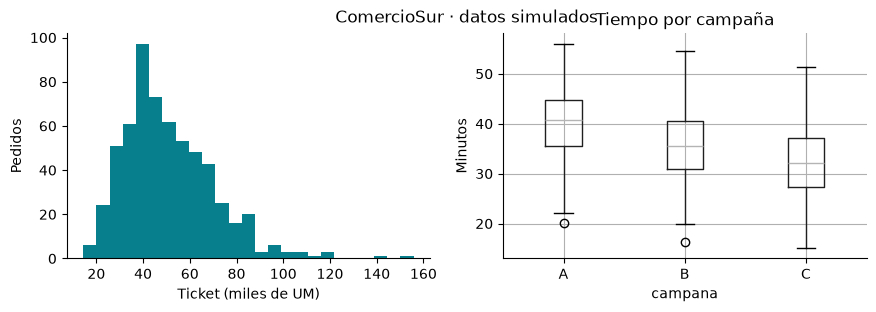

In [3]:
display(df[['ticket_mil','tiempo_min']].describe(percentiles=[.25,.5,.75])); print('IQR ticket:',df.ticket_mil.quantile(.75)-df.ticket_mil.quantile(.25)); fig,ax=plt.subplots(1,2,figsize=(10,3)); ax[0].hist(df.ticket_mil,bins=25,color='#087f8c'); ax[0].set(xlabel='Ticket (miles de UM)',ylabel='Pedidos'); df.boxplot(column='tiempo_min',by='campana',ax=ax[1]); ax[1].set(ylabel='Minutos',title='Tiempo por campaña'); fig.suptitle('ComercioSur · datos simulados'); plt.show()

<a id="calidad"></a>
## Calidad antes del cálculo

Una copia de trabajo contiene aquí un vacío, un duplicado y un tiempo imposible introducidos deliberadamente. Registrar es distinto de eliminar extremos válidos. Nunca se modifica el CSV original.

In [4]:
sucio=pd.concat([df,df.iloc[[0]]],ignore_index=True); sucio.loc[1,'ticket_mil']=np.nan; sucio.loc[2,'tiempo_min']=-5; display(pd.Series({'duplicados_id':sucio.id.duplicated().sum(),'tickets_faltantes':sucio.ticket_mil.isna().sum(),'tiempos_negativos':sucio.tiempo_min.lt(0).sum()})); assert len(pedidos())==600

duplicados_id        1
tickets_faltantes    1
tiempos_negativos    1
dtype: int64

<a id="muestreo"></a>
## Aleatorio, estratificado y conveniencia

En estratificación desproporcionada se ponderan medias de estratos con pesos poblacionales conocidos. Comparar una muestra aleatoria de 200, una de 100 por canal y una muestra solo Web. El sesgo no desaparece aumentando n dentro de un marco incompleto.

In [5]:
pop=poblacion(); simple=pop.sample(n=200,random_state=SEMILLA); estr=pop.groupby('canal',group_keys=False).sample(n=100,random_state=SEMILLA); W=pop.canal.value_counts(normalize=True); pond=(estr.groupby('canal').ticket_mil.mean()*W).sum(); display(pd.Series({'poblacion':pop.ticket_mil.mean(),'aleatoria':simple.ticket_mil.mean(),'estratificada_ponderada':pond,'estratificada_sin_pesos':estr.ticket_mil.mean(),'conveniencia_Web':pop.query("canal=='Web'").sample(200,random_state=SEMILLA).ticket_mil.mean()}))

poblacion                  51.474256
aleatoria                  49.617050
estratificada_ponderada    51.889757
estratificada_sin_pesos    52.297550
conveniencia_Web           49.498200
dtype: float64

<a id="precision"></a>
## Tamaño, representatividad y corrección finita

Diseño para una proporción: confianza 95%, margen absoluto 5 puntos porcentuales, p=.5 conservador y N=5.000. Es una aproximación normal de planificación bajo muestreo aleatorio simple; tasa de respuesta no corrige sesgo de no respuesta.

In [6]:
@widgets.interact(error=widgets.FloatSlider(value=.05,min=.02,max=.15,step=.01),respuesta=widgets.FloatSlider(value=.8,min=.4,max=1,step=.1))
def plan(error,respuesta):
    display(tamano_muestra(error=error,respuesta=respuesta))

interactive(children=(FloatSlider(value=0.05, description='error', max=0.15, min=0.02, step=0.01), FloatSlider…

<a id="experimento-muestreo"></a>
## Variabilidad entre muestras

Modifique n y compare el SD empírico de las medias con S/√n × √(1−n/N). Aquí S usa ddof=1 en el marco y se muestrea sin reemplazo. Actividad: explique por qué el error tiende a cero al observar toda esta población, pero no para pedidos futuros.

In [7]:
@widgets.interact(n=widgets.IntSlider(value=200,min=50,max=1000,step=50))
def muestras(n):
    rng=np.random.default_rng(SEMILLA); x=pop.ticket_mil.to_numpy(); medias=np.array([rng.choice(x,n,replace=False).mean() for _ in range(500)]); teorico=x.std(ddof=1)/np.sqrt(n)*np.sqrt(1-n/len(x))
    print(f'Media poblacional {x.mean():.2f}; SD simulado {medias.std(ddof=1):.3f}; SE teórico {teorico:.3f}')
    plt.hist(medias,bins=25);plt.axvline(x.mean(),color='red');plt.xlabel('Media muestral (miles de UM)');plt.show()

interactive(children=(IntSlider(value=200, description='n', max=1000, min=50, step=50), Output()), _dom_classe…

## Comprobación y entrega

Responda la autoevaluación y complete la actividad del último bloque. Entregue objetivo, método, supuesto, resultado con unidades y decisión condicionada. Las soluciones orientadoras permiten estudiar, pero no sustituyen su interpretación.

In [8]:
auto_01=pregunta('¿Una muestra Web muy grande representa automáticamente a todos los clientes?','Sí, basta con aumentar n','No, el marco excluye clientes de tienda','La precisión dentro de un grupo no elimina el sesgo de cobertura.')
display(auto_01)